<a href="https://colab.research.google.com/github/joostmeyer26/AI_Engineer_Project_2/blob/main/Machine_Learning_Analysis_Hitters_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Analysis: Hitters Dataset
We will start by loading the dataset and inspecting its contents to prepare for predictive modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/drive/MyDrive/AI Engineer All Courses July 2026/Course 5 MS AI : Machine Learning using Python/datasets (3)/Lesson_03_Supervised_Learning_ Regression_and_its_Application/Hitters.csv'
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (322, 21)


,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

None

In [ ]:
# Check for missing values and summary statistics
print("Missing values per column:")
print(df.isnull().sum())

display(df.describe())

Missing values per column:
Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


Since 'Salary' is often the target variable in this dataset, let's visualize its distribution. We should also handle any missing values found above.

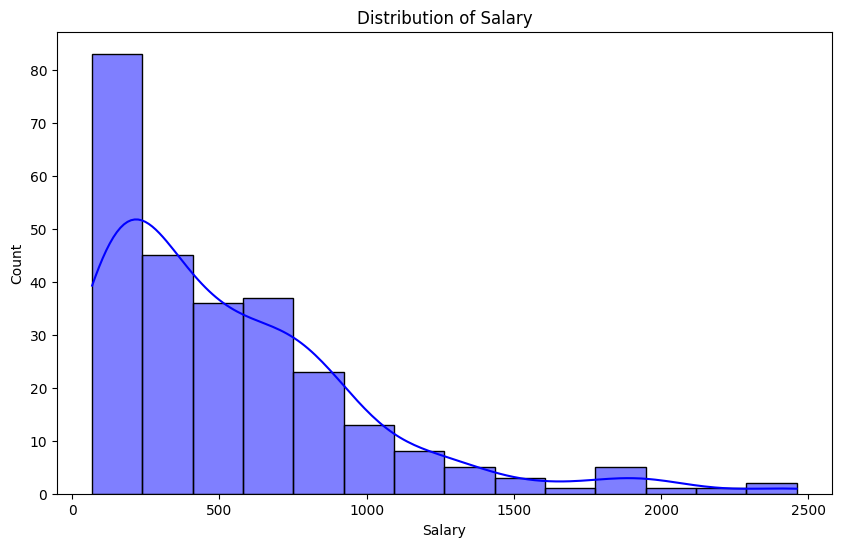

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'].dropna(), kde=True, color='blue')
plt.title('Distribution of Salary')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
file_path= file_path = '/content/drive/MyDrive/AI Engineer All Courses July 2026/Course 5 MS AI : Machine Learning using Python/datasets (3)/Lesson_03_Supervised_Learning_ Regression_and_its_Application/Hitters.csv'
print ("Dataset_Shape", df.shape )
display (df.head())
display (df.info())

Dataset_Shape (322, 21)


,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

None

In [ ]:
# Check for missing values and summary statistics
print("Missing values per column:")
print(df.isnull().sum())

display(df.describe)
print

display (df.describe())

Missing values per column:
Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64


<bound method NDFrame.describe of             Unnamed: 0  AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  \
0       -Andy Allanson    293    66      1    30   29     14      1     293   
1          -Alan Ashby    315    81      7    24   38     39     14    3449   
2         -Alvin Davis    479   130     18    66   72     76      3    1624   
3        -Andre Dawson    496   141     20    65   78     37     11    5628   
4    -Andres Galarraga    321    87     10    39   42     30      2     396   
..                 ...    ...   ...    ...   ...  ...    ...    ...     ...   
317      -Willie McGee    497   127      7    65   48     37      5    2703   
318   -Willie Randolph    492   136      5    76   50     94     12    5511   
319    -Wayne Tolleson    475   126      3    61   43     52      6    1700   
320     -Willie Upshaw    573   144      9    85   60     78      8    3198   
321     -Willie Wilson    631   170      9    77   44     31     11    4908   

     CHits  ...  CRuns  CRBI  CWalks  League Division PutOuts  Assists  \
0       66  ...     30    29      14       A        E     446       33   
1      835  ...    321   414     375       N        W     632       43   
2      457  ...    224   266     263       A        W     880       82   
3     1575  ...    828   838     354       N        E     200       11   
4      101  ...     48    46      33       N        E     805       40   
..     ...  ...    ...   ...     ...     ...      ...     ...      ...   
317    806  ...    379   311     138       N        E     325        9   
318   1511  ...    897   451     875       A        E     313      381   
319    433  ...    217    93     146       A        W      37      113   
320    857  ...    470   420     332       A        E    1314      131   
321   1457  ...    775   357     249       A        W     408        4   

     Errors  Salary  NewLeague  
0        20     NaN          A  
1        10   475.0          N  
2        14   480.0          A  
3         3   500.0          N  
4         4    91.5          N  
..      ...     ...        ...  
317       3   700.0          N  
318      20   875.0          A  
319       7   385.0          A  
320      12   960.0          A  
321       3  1000.0          A  

[322 rows x 21 columns]>

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [ ]:
# 1. Drop rows where 'Salary' is missing
df_clean = df.dropna(subset=['Salary'])

# 2. Drop the player name column ('Unnamed: 0')
df_clean = df_clean.drop(columns=['Unnamed: 0'])

# 3. Convert categorical variables to dummy variables (One-Hot Encoding)
# We set drop_first=True to avoid the dummy variable trap
df_final = pd.get_dummies(df_clean, columns=['League', 'Division', 'NewLeague'], drop_first=True)

# Check the new shape and first few rows
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_final.shape}")
display(df_final.head())

Original shape: (322, 21)
Cleaned shape: (263, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [ ]:
df_clean= df.dropna (subset=['Salary'])
df_clean= df_clean.drop (columns=['Unnamed: 0'])
df_final= pd.get_dummies (df_clean, columns=['League', 'Division', 'NewLeague'], drop_first=True)
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_final.shape}")
display(df_final.head())

Original shape: (322, 21)
Cleaned shape: (263, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


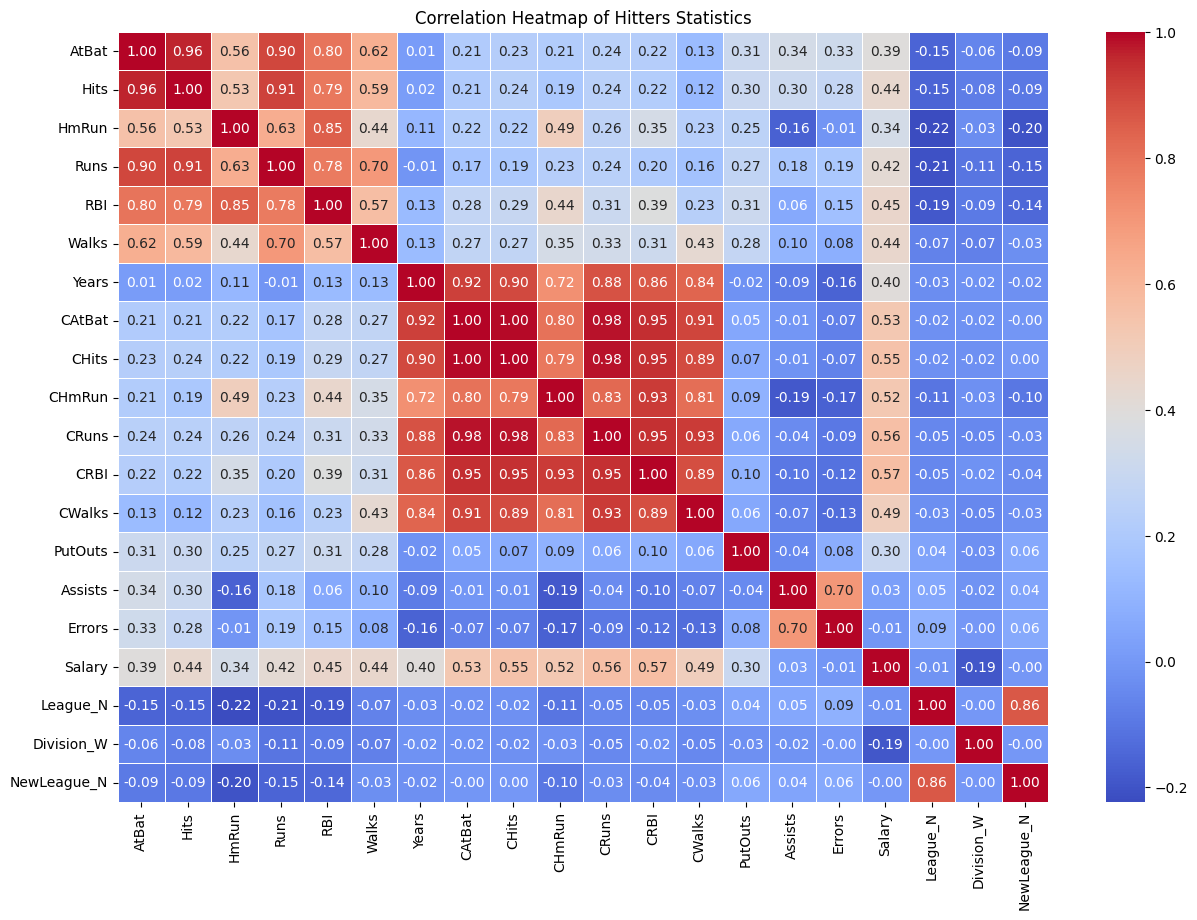

Correlations with Salary:
Salary         1.000000
CRBI           0.566966
CRuns          0.562678
CHits          0.548910
CAtBat         0.526135
CHmRun         0.524931
CWalks         0.489822
RBI            0.449457
Walks          0.443867
Hits           0.438675
Runs           0.419859
Years          0.400657
AtBat          0.394771
HmRun          0.343028
PutOuts        0.300480
Assists        0.025436
NewLeague_N   -0.002834
Errors        -0.005401
League_N      -0.014282
Division_W    -0.192514
Name: Salary, dtype: float64


In [ ]:
# Calculate the correlation matrix
corr_matrix = df_final.corr()

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Hitters Statistics')
plt.show()

# Specifically look at correlations with Salary
salary_correlations = corr_matrix['Salary'].sort_values(ascending=False)
print("Correlations with Salary:")
print(salary_correlations)

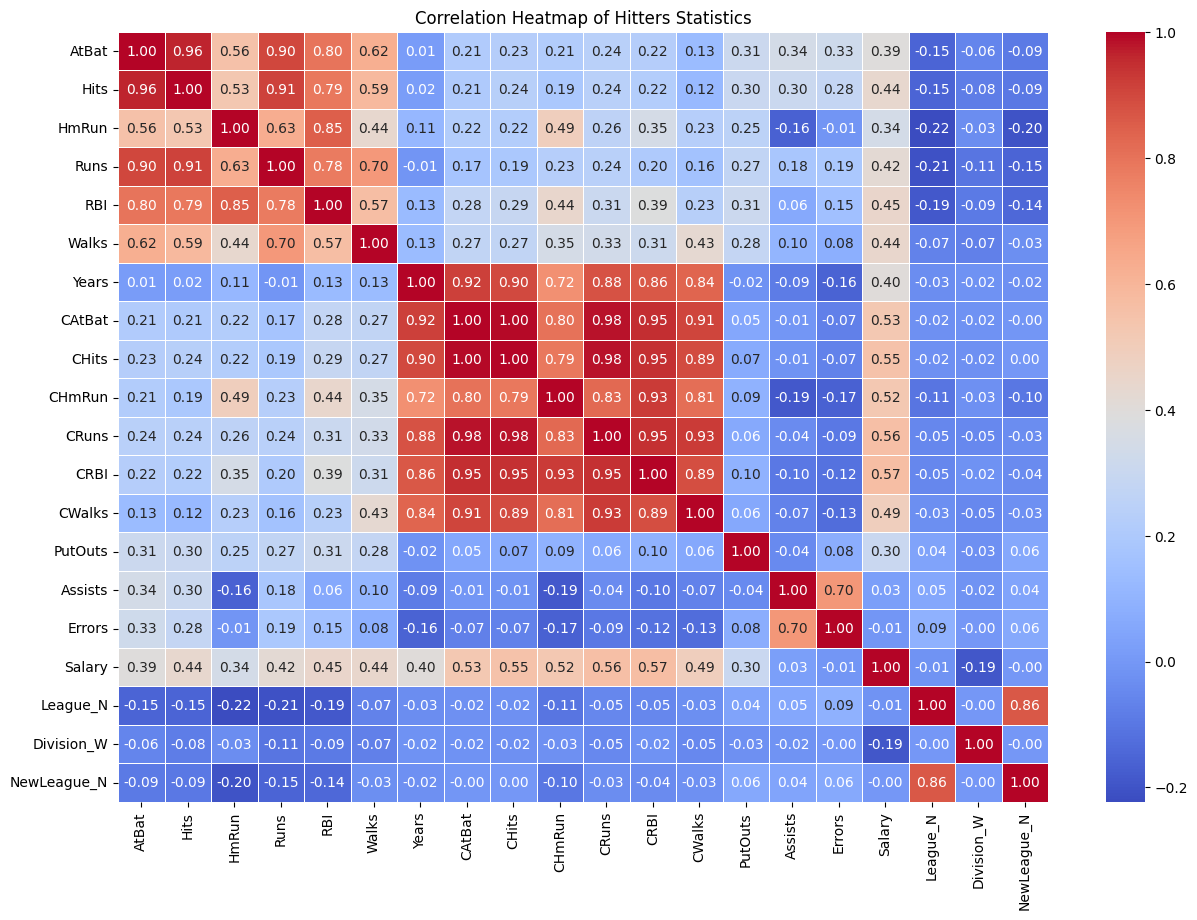

Correlations with Salary:
Salary         1.000000
CRBI           0.566966
CRuns          0.562678
CHits          0.548910
CAtBat         0.526135
CHmRun         0.524931
CWalks         0.489822
RBI            0.449457
Walks          0.443867
Hits           0.438675
Runs           0.419859
Years          0.400657
AtBat          0.394771
HmRun          0.343028
PutOuts        0.300480
Assists        0.025436
NewLeague_N   -0.002834
Errors        -0.005401
League_N      -0.014282
Division_W    -0.192514
Name: Salary, dtype: float64


In [ ]:
corr_matrix = df_final.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Hitters Statistics')
plt.show()

salary_correlations = corr_matrix['Salary'].sort_values(ascending=False)
print("Correlations with Salary:")
print(salary_correlations)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df_final.drop('Salary', axis=1)
y = df_final['Salary']

# 2. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print("Data splitting and scaling complete!")

Training set shape: (210, 19)
Test set shape: (53, 19)
Data splitting and scaling complete!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_final.drop('Salary', axis=1)
y = df_final['Salary']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Training set shape: {x_train_scaled.shape}")
print(f"Test set shape: {x_test_scaled.shape}")
print("Data splitting and scaling complete!")

Training set shape: (210, 19)
Test set shape: (53, 19)
Data splitting and scaling complete!


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

# 2. Make predictions on the test set
y_pred = lr_model.predict(x_test_scaled)

# 3. Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Linear Regression Results ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Display the coefficients to see which features the model thinks are important
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print("\nModel Coefficients (Top 5):")
display(coeffs.sort_values(by='Coefficient', ascending=False).head())


--- Linear Regression Results ---
Mean Squared Error (MSE): 128284.35
R-squared (R2) Score: 0.2907

Model Coefficients (Top 5):


,Feature,Coefficient
10,CRuns,574.500346
1,Hits,325.155262
11,CRBI,311.828505
5,Walks,116.936215
13,PutOuts,74.879063


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)
y_pred = lr_model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Linear Regression Results ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
print("\nModel Coefficients (Top 5):")
display(coeffs.sort_values(by='Coefficient', ascending=False).head())

--- Linear Regression Results ---
Mean Squared Error (MSE): 128284.35
R-squared (R2) Score: 0.2907

Model Coefficients (Top 5):


,Feature,Coefficient
10,CRuns,574.500346
1,Hits,325.155262
11,CRBI,311.828505
5,Walks,116.936215
13,PutOuts,74.879063


In [ ]:
from sklearn.linear_model import Ridge, Lasso

# 1. Ridge Regression (L2 Regularization)
ridge_model = Ridge(alpha=1.0) # alpha is the penalty strength
ridge_model.fit(x_train_scaled, y_train)
ridge_pred = ridge_model.predict(x_test_scaled)

# 2. Lasso Regression (L1 Regularization)
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train_scaled, y_train)
lasso_pred = lasso_model.predict(x_test_scaled)

# 3. Evaluate Performance
print("--- Ridge Regression Results ---")
print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, ridge_pred):.4f}")

print("\n--- Lasso Regression Results ---")
print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, lasso_pred):.4f}")

# Compare non-zero coefficients in Lasso
lasso_coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_model.coef_})
print("\nLasso Features with non-zero coefficients:")
display(lasso_coeffs[lasso_coeffs['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False))

--- Ridge Regression Results ---
MSE: 126718.59
R2 Score: 0.2994

--- Lasso Regression Results ---
MSE: 126527.02
R2 Score: 0.3005

Lasso Features with non-zero coefficients:


,Feature,Coefficient
10,CRuns,405.052380
1,Hits,292.808927
11,CRBI,208.290219
5,Walks,99.733559
13,PutOuts,75.742610
16,League_N,41.819190
14,Assists,19.689064
2,HmRun,13.017795
4,RBI,-1.317280
15,Errors,-5.794933


In [ ]:
from sklearn.linear_model import Ridge, Lasso

# 1. Ridge Regression (L2 Regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_scaled, y_train)
ridge_pred = ridge_model.predict(x_test_scaled)

# 2. Lasso Regression (L1 Regularization)
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train_scaled, y_train)
# FIX: Added parentheses and the test data to call the predict method
lasso_pred = lasso_model.predict(x_test_scaled)

# 3. Evaluate Performance
print("--- Ridge Regression Results ---")
print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, ridge_pred):.4f}")

print("\n--- Lasso Regression Results ---")
print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, lasso_pred):.4f}")

# Compare non-zero coefficients in Lasso
lasso_coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_model.coef_})
print("\nLasso Features with non-zero coefficients:")
display(lasso_coeffs[lasso_coeffs['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False))

--- Ridge Regression Results ---
MSE: 126718.59
R2 Score: 0.2994

--- Lasso Regression Results ---
MSE: 126527.02
R2 Score: 0.3005

Lasso Features with non-zero coefficients:


,Feature,Coefficient
10,CRuns,405.052380
1,Hits,292.808927
11,CRBI,208.290219
5,Walks,99.733559
13,PutOuts,75.742610
16,League_N,41.819190
14,Assists,19.689064
2,HmRun,13.017795
4,RBI,-1.317280
15,Errors,-5.794933


### Testing a Non-Linear Model: Random Forest Regressor
Random Forest can capture complex interactions between features that Linear Regression might miss.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)

# 2. Make predictions
rf_pred = rf_model.predict(x_test_scaled)

# 3. Evaluate
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"--- Random Forest Results ---")
print(f"MSE: {rf_mse:.2f}")
print(f"R2 Score: {rf_r2:.4f}")

# 4. Feature Importance
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
display(importances.sort_values(by='Importance', ascending=False).head(10))

--- Random Forest Results ---
MSE: 93088.48
R2 Score: 0.4853


,Feature,Importance
11,CRBI,0.223834
8,CHits,0.223809
4,RBI,0.073616
5,Walks,0.065505
3,Runs,0.056834
9,CHmRun,0.056507
13,PutOuts,0.045785
10,CRuns,0.045717
1,Hits,0.045207
0,AtBat,0.037627


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_scaled, y_train)

# 2. Make predictions
rf_pred = rf_model.predict(x_test_scaled)

# 3. Evaluate
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"--- Random Forest Results ---")
print(f"MSE: {rf_mse:.2f}")
print(f"R2 Score: {rf_r2:.4f}")

importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
display(importances.sort_values(by='Importance', ascending=False).head(10))

--- Random Forest Results ---
MSE: 93088.48
R2 Score: 0.4853


,Feature,Importance
11,CRBI,0.223834
8,CHits,0.223809
4,RBI,0.073616
5,Walks,0.065505
3,Runs,0.056834
9,CHmRun,0.056507
13,PutOuts,0.045785
10,CRuns,0.045717
1,Hits,0.045207
0,AtBat,0.037627


### Step 6: Feature Engineering
In this step, we transform raw data into more meaningful indicators. This helps the model identify patterns that might be hidden in absolute numbers.

In [ ]:
# Create a copy for engineering
df_eng = df_final.copy()

# 1. Batting Average (Hits per At-Bat)
df_eng['BattingAvg'] = df_eng['Hits'] / (df_eng['AtBat'] + 1)

# 2. Home Run Efficiency (Power per At-Bat)
df_eng['HR_Efficiency'] = df_eng['HmRun'] / (df_eng['AtBat'] + 1)

# 3. Career RBI Productivity (Average RBIs per Year played)
df_eng['CRBI_per_Year'] = df_eng['CRBI'] / (df_eng['Years'] + 1)

# Display the new columns
display(df_eng[['BattingAvg', 'HR_Efficiency', 'CRBI_per_Year', 'Salary']].head())

# Let's check the correlation of our new features with Salary
new_corr = df_eng[['BattingAvg', 'HR_Efficiency', 'CRBI_per_Year', 'Salary']].corr()['Salary']
print("\nNew Features Correlation with Salary:")
print(new_corr)

,BattingAvg,HR_Efficiency,CRBI_per_Year,Salary
1,0.256329,0.022152,27.600000,475.0
2,0.270833,0.037500,66.500000,480.0
3,0.283702,0.040241,69.833333,500.0
4,0.270186,0.031056,15.333333,91.5
5,0.284034,0.006723,28.000000,750.0



New Features Correlation with Salary:
BattingAvg       0.198941
HR_Efficiency    0.150931
CRBI_per_Year    0.674232
Salary           1.000000
Name: Salary, dtype: float64


In [ ]:
df_eng = df_final.copy()
df_eng['BattingAvg'] = df_eng['Hits'] / (df_eng['AtBat'] + 1)
df_eng['HR_Efficiency'] = df_eng['HmRun'] / (df_eng['AtBat'] + 1)
df_eng['CRBI_per_Year'] = df_eng['CRBI'] / (df_eng['Years'] + 1)
display(df_eng[['BattingAvg', 'HR_Efficiency', 'CRBI_per_Year', 'Salary']].head())
new_corr = df_eng[['BattingAvg', 'HR_Efficiency', 'CRBI_per_Year', 'Salary']].corr()['Salary']
print("\nNew Features Correlation with Salary:")
print(new_corr)

,BattingAvg,HR_Efficiency,CRBI_per_Year,Salary
1,0.256329,0.022152,27.600000,475.0
2,0.270833,0.037500,66.500000,480.0
3,0.283702,0.040241,69.833333,500.0
4,0.270186,0.031056,15.333333,91.5
5,0.284034,0.006723,28.000000,750.0



New Features Correlation with Salary:
BattingAvg       0.198941
HR_Efficiency    0.150931
CRBI_per_Year    0.674232
Salary           1.000000
Name: Salary, dtype: float64


### Step 6: Advanced Modeling & Feature Engineering
We will create a new feature to represent efficiency and try Gradient Boosting to see if we can exceed the 50% R2 threshold.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Simple Feature Engineering: Batting Average
# We use the original df_final to avoid scaling issues during creation
df_eng = df_final.copy()
df_eng['BattingAvg'] = df_eng['Hits'] / (df_eng['AtBat'] + 1) # +1 to avoid division by zero

# 2. Re-prepare data with the new feature
X_eng = df_eng.drop('Salary', axis=1)
y_eng = df_eng['Salary']
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

# 3. Train Gradient Boosting Model
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train_e, y_train_e)

# 4. Evaluate
hgb_pred = hgb_model.predict(X_test_e)
hgb_r2 = r2_score(y_test_e, hgb_pred)

print(f"--- Gradient Boosting Results ---")
print(f"MSE: {mean_squared_error(y_test_e, hgb_pred):.2f}")
print(f"R2 Score: {hgb_r2:.4f}")

--- Gradient Boosting Results ---
MSE: 128766.02
R2 Score: 0.2881


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Feature Engineering
df_eng = df_final.copy()
df_eng['BattingAvg'] = df_eng['Hits'] / (df_eng['AtBat'] + 1)

# 2. Re-prepare data
x_eng = df_eng.drop('Salary', axis=1)
y_eng = df_eng['Salary']
x_train_e, x_test_e, y_train_e, y_test_e = train_test_split(x_eng, y_eng, test_size=0.2, random_state=42)

# 3. Train Gradient Boosting Model
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(x_train_e, y_train_e)

# 4. Evaluate using consistent variable names
hgb_pred = hgb_model.predict(x_test_e)
hgb_r2 = r2_score(y_test_e, hgb_pred)

print(f"--- Gradient Boosting Results ---")
print(f"MSE: {mean_squared_error(y_test_e, hgb_pred):.2f}")
print(f"R2 Score: {hgb_r2:.4f}")

--- Gradient Boosting Results ---
MSE: 128766.02
R2 Score: 0.2881


### Step 7: Random Forest with Engineered Features
Now we combine our best model (Random Forest) with our new engineered features to see if we can achieve a new high score for R2.

In [ ]:
# 1. Prepare data with all engineered features
X_final_eng = df_eng.drop('Salary', axis=1)
y_final_eng = df_eng['Salary']

# 2. Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_eng, y_final_eng, test_size=0.2, random_state=42)

# 3. Train Random Forest on the enhanced dataset
rf_eng_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_eng_model.fit(X_train_f, y_train_f)

# 4. Evaluate
rf_eng_pred = rf_eng_model.predict(X_test_f)
rf_eng_r2 = r2_score(y_test_f, rf_eng_pred)

print(f"--- Enhanced Random Forest Results ---")
print(f"MSE: {mean_squared_error(y_test_f, rf_eng_pred):.2f}")
print(f"R2 Score: {rf_eng_r2:.4f}")

# 5. Check Feature Importance to see if our new features helped
eng_importances = pd.DataFrame({'Feature': X_final_eng.columns, 'Importance': rf_eng_model.feature_importances_})
display(eng_importances.sort_values(by='Importance', ascending=False).head(10))

--- Enhanced Random Forest Results ---
MSE: 95617.28
R2 Score: 0.4714


,Feature,Importance
8,CHits,0.219591
11,CRBI,0.218895
4,RBI,0.072405
5,Walks,0.062888
3,Runs,0.055354
9,CHmRun,0.053919
10,CRuns,0.043937
13,PutOuts,0.042787
19,BattingAvg,0.041902
0,AtBat,0.038025


In [ ]:
X_final_eng = df_eng.drop('Salary', axis=1)
y_final_eng = df_eng['Salary']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_eng, y_final_eng, test_size=0.2, random_state=42)
rf_eng_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_eng_model.fit(X_train_f, y_train_f)
rf_eng_pred = rf_eng_model.predict(X_test_f)
rf_eng_r2 = r2_score(y_test_f, rf_eng_pred)
print(f"--- Enhanced Random Forest Results ---")
print(f"MSE: {mean_squared_error(y_test_f, rf_eng_pred):.2f}")
print(f"R2 Score: {rf_eng_r2:.4f}")

eng_importances = pd.DataFrame({'Feature': X_final_eng.columns, 'Importance': rf_eng_model.feature_importances_})
display(eng_importances.sort_values(by='Importance', ascending=False).head(10))



--- Enhanced Random Forest Results ---
MSE: 95617.28
R2 Score: 0.4714


,Feature,Importance
8,CHits,0.219591
11,CRBI,0.218895
4,RBI,0.072405
5,Walks,0.062888
3,Runs,0.055354
9,CHmRun,0.053919
10,CRuns,0.043937
13,PutOuts,0.042787
19,BattingAvg,0.041902
0,AtBat,0.038025


### Step 8: Hyperparameter Tuning (Grid Search)
Instead of using the default settings, we will test multiple combinations of `max_depth` and `n_estimators` to find the optimal configuration for our engineered dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize Grid Search
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

# 3. Fit the grid search
grid_search.fit(X_train_f, y_train_f)

# 4. Best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R2: {grid_search.best_score_:.4f}")

# 5. Evaluate best model on test set
best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test_f)
tuned_r2 = r2_score(y_test_f, tuned_pred)

print(f"\n--- Tuned Random Forest Results ---")
print(f"Final Test R2 Score: {tuned_r2:.4f}")

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation R2: 0.6506

--- Tuned Random Forest Results ---
Final Test R2 Score: 0.4481


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize Grid Search
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)

# 3. Fit the grid search
grid_search.fit(X_train_f, y_train_f)

# 4. Display Best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R2: {grid_search.best_score_:.4f}")

# 5. Evaluate best model on test set
best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test_f)
tuned_r2 = r2_score(y_test_f, tuned_pred)

print(f"\n--- Tuned Random Forest Results ---")
print(f"Final Test R2 Score: {tuned_r2:.4f}")

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation R2: 0.6506

--- Tuned Random Forest Results ---
Final Test R2 Score: 0.4481


### Step 9: Advanced Modeling with XGBoost
XGBoost often provides better performance through boosting. We will implement it with hyperparameter tuning to see if we can improve our R2 score.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# 1. Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 2. Define a parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# 3. Initialize Grid Search
xgb_grid = GridSearchCV(estimator=xgb_model,
                        param_grid=xgb_param_grid,
                        cv=5,
                        scoring='r2',
                        n_jobs=-1)

# 4. Fit the model
xgb_grid.fit(X_train_f, y_train_f)

# 5. Evaluate the best XGBoost model
best_xgb = xgb_grid.best_estimator_
xgb_tuned_pred = best_xgb.predict(X_test_f)
xgb_r2 = r2_score(y_test_f, xgb_tuned_pred)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best CV R2 Score: {xgb_grid.best_score_:.4f}")
print(f"Final XGBoost Test R2 Score: {xgb_r2:.4f}")

Best XGBoost Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2 Score: 0.6777
Final XGBoost Test R2 Score: 0.5398


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# 1. Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 2. Define a parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(estimator=xgb_model,
                        param_grid=xgb_param_grid,
                        cv=5,
                        scoring='r2',
                        n_jobs=-1)
# FIXED: Changed x_train_f to X_train_f
xgb_grid.fit(X_train_f, y_train_f)

best_xgb = xgb_grid.best_estimator_
xgb_tuned_pred = best_xgb.predict(X_test_f)
# FIXED: Standardized variable name to xgb_r2
xgb_r2 = r2_score(y_test_f, xgb_tuned_pred)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best CV R2 Score: {xgb_grid.best_score_:.4f}")
print(f"Final XGBoost Test R2 Score: {xgb_r2:.4f}")

Best XGBoost Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2 Score: 0.6777
Final XGBoost Test R2 Score: 0.5398


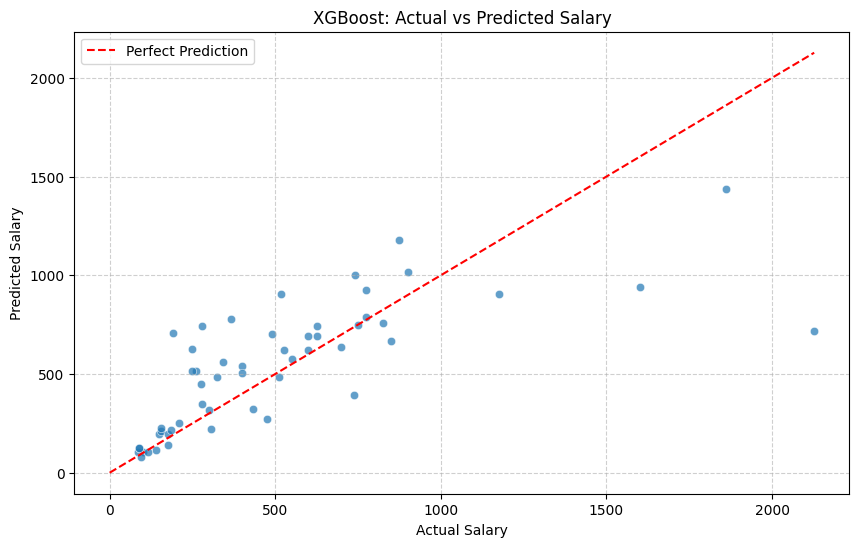

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_f, y=xgb_tuned_pred, alpha=0.7)

# Add a line representing perfect prediction
max_val = max(max(y_test_f), max(xgb_tuned_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('XGBoost: Actual vs Predicted Salary')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Step 11: Model Comparison
We will now compare the performance of the tuned Random Forest and the tuned XGBoost model to quantify the improvements.

Model Performance Comparison:


,Model,R2 Score,MSE
0,Tuned Random Forest,0.448141,99815.809468
1,Tuned XGBoost,0.539814,83234.721652


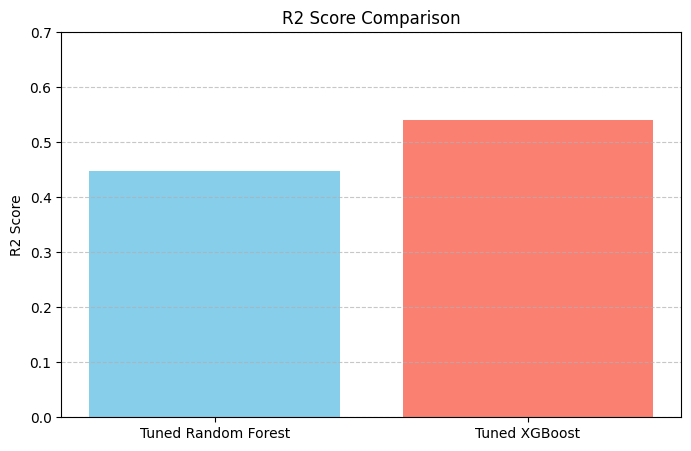

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate MSE for both tuned models
from sklearn.metrics import mean_squared_error

rf_tuned_mse = mean_squared_error(y_test_f, tuned_pred)
xgb_tuned_mse = mean_squared_error(y_test_f, xgb_tuned_pred)

# Create a comparison DataFrame
comparison_metrics = pd.DataFrame({
    'Model': ['Tuned Random Forest', 'Tuned XGBoost'],
    'R2 Score': [tuned_r2, xgb_r2],
    'MSE': [rf_tuned_mse, xgb_tuned_mse]
})

print("Model Performance Comparison:")
display(comparison_metrics)

# Plotting R2 Comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_metrics['Model'], comparison_metrics['R2 Score'], color=['skyblue', 'salmon'])
plt.title('R2 Score Comparison')
plt.ylabel('R2 Score')
plt.ylim(0, 0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()